In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END
from IPython.display import Image
from nodes.vision_node import vision_node
from nodes.risk_node import risk_node
from nodes.home_node import home_node
from nodes.hospital_node import hospital_node


class TriageState(TypedDict):
    image_url: str
    vision_json: dict
    risk_level: str
    final_output: dict


def route(state: TriageState) -> Literal["hospital", "home"]:
    if state["risk_level"] == "HIGH":
        return "hospital"
    return "home"


def build_graph():
    graph = StateGraph(TriageState)

    graph.add_node("vision", vision_node)
    graph.add_node("risk", risk_node)
    graph.add_node("home", home_node)
    graph.add_node("hospital", hospital_node)

    graph.set_entry_point("vision")
    graph.add_edge("vision", "risk")

    graph.add_conditional_edges(
        "risk",
        route,
        {
            "hospital": "hospital",
            "home": "home"
        }
    )

    graph.add_edge("hospital", END)
    graph.add_edge("home", END)

    return graph.compile()


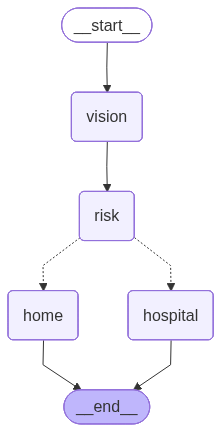

In [6]:
app = build_graph()
display(Image(app.get_graph().draw_mermaid_png()))